In [1]:
pip install pandas numpy nltk scikit-learn gensim matplotlib seaborn pdfplumber textblob

Note: you may need to restart the kernel to use updated packages.


# Part I: Text Analysis

In [2]:
import pdfplumber

def extract_text_from_pdf(file_path):
    text = ""
    try:
        with pdfplumber.open(file_path) as pdf:
            for i, page in enumerate(pdf.pages):
                extracted = page.extract_text()
                if extracted:
                    text += extracted + "\n"
                else:
                    print(f"Warning: No text found on page {i}")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
    return text

### Loading the PDF files & removing junk: 10K and earnings report

In [5]:
tenk_text = extract_text_from_pdf("data/nvidia_10k.pdf")
earnings_text = extract_text_from_pdf("data/nvidia_earnings.pdf")

In [4]:
import re

def clean_text(text):
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)     # keep only letters + spaces
    text = re.sub(r'\s+', ' ', text)             # normalise whitespace
    return text.strip()

In [6]:
tenk_text = clean_text(tenk_text)
earnings_text = clean_text(earnings_text)

# Trim earnings call to start at first operator cue
start_index = earnings_text.lower().find("operator")
if start_index != -1:
    earnings_text = earnings_text[start_index:]

print("10-K length (words)      :", len(tenk_text.split()))
print("Earnings length (words)  :", len(earnings_text.split()))
print("\n10-K preview:\n", tenk_text[:300])
print("\nEarnings preview:\n", earnings_text[:300])

10-K length (words)      : 51308
Earnings length (words)  : 5912

10-K preview:
 Table of Contents UNITED STATES SECURITIES AND EXCHANGE COMMISSION Washington D C FORM K ANNUAL REPORT PURSUANT TO SECTION OR d OF THE SECURITIES EXCHANGE ACT OF For the fiscal year ended January OR TRANSITION REPORT PURSUANT TO SECTION OR d OF THE SECURITIES EXCHANGE ACT OF Commission file number N

Earnings preview:
 Operator would you please poll for questions Sarah Thank you At this time I would like to remind everyone in order to ask a question press star then the number one on your telephone keypad Thank you Your prst question comes from Joseph Moore with Morgan Stanley Your line is open Great Thank you I wo


### Keyword analysis

In [8]:
import pandas as pd

keywords = [
    "taiwan", "tsmc", "china", "geopolitical",
    "risk", "supply", "manufacturing", "semiconductor"
]

def keyword_counts(text, keywords):
    text_lower = text.lower()
    counts = {}
    for word in keywords:
        pattern = r'\b' + re.escape(word) + r'\b'
        counts[word] = len(re.findall(pattern, text_lower))
    return counts

tenk_counts    = keyword_counts(tenk_text, keywords)
earnings_counts = keyword_counts(earnings_text, keywords)

print("10-K Counts:\n",      tenk_counts)
print("\nEarnings Call Counts:\n", earnings_counts)

10-K Counts:
 {'taiwan': 10, 'tsmc': 1, 'china': 74, 'geopolitical': 11, 'risk': 46, 'supply': 77, 'manufacturing': 41, 'semiconductor': 14}

Earnings Call Counts:
 {'taiwan': 0, 'tsmc': 1, 'china': 0, 'geopolitical': 0, 'risk': 0, 'supply': 18, 'manufacturing': 0, 'semiconductor': 0}


In [9]:
df = pd.DataFrame({
    "Keyword": keywords,
    "10-K": [tenk_counts[k] for k in keywords],
    "Earnings Call": [earnings_counts[k] for k in keywords]
})

df

,Keyword,10-K,Earnings Call
0,taiwan,10,0
1,tsmc,1,1
2,china,74,0
3,geopolitical,11,0
4,risk,46,0
5,supply,77,18
6,manufacturing,41,0
7,semiconductor,14,0


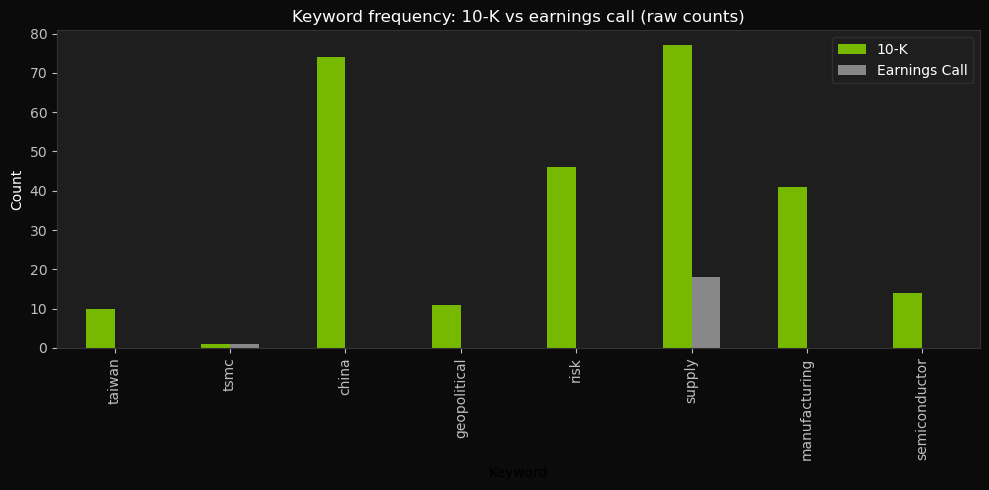

In [29]:
import matplotlib.pyplot as plt

bg_color = "#0B0B0B"
axes_color = "#1E1E1E"
text_color = "#FFFFFF"
secondary_text = "#BFBFBF"
nvidia_green = "#76B900"
neutral_gray = "#888888"

fig, ax = plt.subplots(figsize=(10, 5), facecolor=bg_color)
ax.set_facecolor(axes_color)

df.set_index("Keyword").plot(
    kind="bar",
    ax=ax,
    color=[nvidia_green, neutral_gray],
    edgecolor="none"
)

# Titles and labels
ax.set_title(
    "Keyword frequency: 10-K vs earnings call (raw counts)",
    color=text_color,
    fontsize=12
)
ax.set_ylabel("Count", color=text_color)

# Ticks styling
ax.tick_params(axis='x', colors=secondary_text, rotation=90)
ax.tick_params(axis='y', colors=secondary_text)

# Legend styling
legend = ax.legend(facecolor=axes_color, edgecolor="#333333")
for text in legend.get_texts():
    text.set_color(text_color)

# Borders
for spine in ax.spines.values():
    spine.set_color("#333333")

plt.tight_layout()
plt.savefig("Keyword Frequency (Raw).png", dpi=300, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

### Normalised keyword frequency (controls for document length)

In [13]:
def normalize_counts(counts, text):
    total_words = len(text.split())
    return {k: v / total_words * 1000 for k, v in counts.items()}   # per 1,000 words

tenk_norm    = normalize_counts(tenk_counts, tenk_text)
earnings_norm = normalize_counts(earnings_counts, earnings_text)

df_norm = pd.DataFrame({
    "Keyword": keywords,
    "10-K (Raw)":          [tenk_counts[k]    for k in keywords],
    "Earnings (Raw)":      [earnings_counts[k] for k in keywords],
    "10-K (per 1k words)": [tenk_norm[k]       for k in keywords],
    "Earn. (per 1k words)":[earnings_norm[k]   for k in keywords]
})

df_norm

,Keyword,10-K (Raw),Earnings (Raw),10-K (per 1k words),Earn. (per 1k words)
0,taiwan,10,0,0.194901,0.000000
1,tsmc,1,1,0.019490,0.169147
2,china,74,0,1.442270,0.000000
3,geopolitical,11,0,0.214392,0.000000
4,risk,46,0,0.896546,0.000000
5,supply,77,18,1.500741,3.044655
6,manufacturing,41,0,0.799096,0.000000
7,semiconductor,14,0,0.272862,0.000000


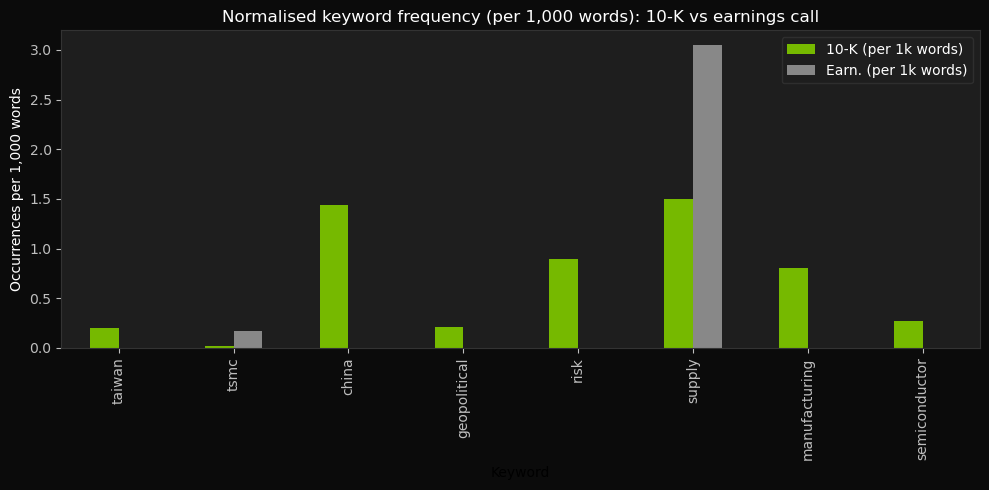

In [28]:
import matplotlib.pyplot as plt

bg_color = "#0B0B0B"
axes_color = "#1E1E1E"
text_color = "#FFFFFF"
secondary_text = "#BFBFBF"
nvidia_green = "#76B900"
neutral_gray = "#888888"

fig, ax = plt.subplots(figsize=(10, 5), facecolor=bg_color)
ax.set_facecolor(axes_color)

df_norm.set_index("Keyword")[["10-K (per 1k words)", "Earn. (per 1k words)"]].plot(
    kind="bar",
    ax=ax,
    color=[nvidia_green, neutral_gray],
    edgecolor="none"
)

# Titles and labels
ax.set_title(
    "Normalised keyword frequency (per 1,000 words): 10-K vs earnings call",
    color=text_color,
    fontsize=12
)
ax.set_ylabel("Occurrences per 1,000 words", color=text_color)

# Ticks styling
ax.tick_params(axis='x', colors=secondary_text, rotation=90)
ax.tick_params(axis='y', colors=secondary_text)

# Legend styling
legend = ax.legend(facecolor=axes_color, edgecolor="#333333")
for text in legend.get_texts():
    text.set_color(text_color)

# Borders
for spine in ax.spines.values():
    spine.set_color("#333333")

plt.tight_layout()
plt.savefig("Keyword Frequency (Normalized).png", dpi=300, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

### Chi-squared test: are keyword frequency differences statistically significant?

A chi-squared test of independence checks whether the distribution of keyword mentions
differs significantly between the 10-K and the earnings call, controlling for document length.

In [15]:
from scipy.stats import chi2_contingency
import numpy as np

# contingency table: rows = keywords, cols = [10-K count, earnings count]
observed = np.array([
    [tenk_counts[k], earnings_counts[k]] for k in keywords
])

chi2, p_value, dof, expected = chi2_contingency(observed)

print(f"Chi-squared statistic : {chi2:.2f}")
print(f"Degrees of freedom    : {dof}")
print(f"p-value               : {p_value:.4e}")
print()

if p_value < 0.05:
    print("Result: The keyword distributions are SIGNIFICANTLY different between the two documents (p < 0.05).")
    print("This statistically supports the hypothesis that NVIDIA uses different language registers")
    print("for formal disclosures vs. investor-facing communications.")
else:
    print("Result: No statistically significant difference detected (p >= 0.05).")

# Per-keyword contribution to chi-squared (Pearson residuals)
residuals = (observed - expected) / np.sqrt(expected)
df_chi = pd.DataFrame(residuals, index=keywords, columns=["10-K residual", "Earnings residual"])
df_chi["contribution"] = (residuals**2).sum(axis=1)
df_chi = df_chi.sort_values("contribution", ascending=False)

print("\nPer-keyword chi-squared contribution (higher = more divergent):")
print(df_chi.round(3))

Chi-squared statistic : 44.17
Degrees of freedom    : 7
p-value               : 1.9823e-07

Result: The keyword distributions are SIGNIFICANTLY different between the two documents (p < 0.05).
This statistically supports the hypothesis that NVIDIA uses different language registers
for formal disclosures vs. investor-facing communications.

Per-keyword chi-squared contribution (higher = more divergent):
               10-K residual  Earnings residual  contribution
supply                -1.256              4.770        24.332
tsmc                  -0.636              2.417         6.245
china                  0.577             -2.191         5.131
risk                   0.455             -1.727         3.190
manufacturing          0.429             -1.631         2.843
semiconductor          0.251             -0.953         0.971
geopolitical           0.222             -0.845         0.763
taiwan                 0.212             -0.805         0.693


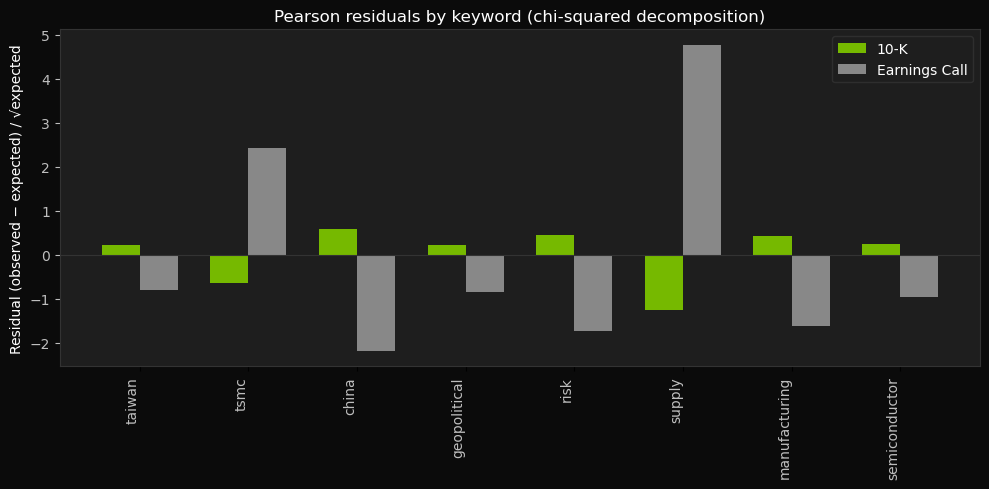

In [30]:
import matplotlib.pyplot as plt
import numpy as np

bg_color = "#0B0B0B"
axes_color = "#1E1E1E"
text_color = "#FFFFFF"
secondary_text = "#BFBFBF"
nvidia_green = "#76B900"
neutral_gray = "#888888"

fig, ax = plt.subplots(figsize=(10, 5), facecolor=bg_color)
ax.set_facecolor(axes_color)

x = np.arange(len(keywords))
width = 0.35

# Bars (green vs gray)
ax.bar(
    x - width/2,
    df_chi.loc[keywords, "10-K residual"],
    width,
    label="10-K",
    color=nvidia_green,
    edgecolor="none"
)

ax.bar(
    x + width/2,
    df_chi.loc[keywords, "Earnings residual"],
    width,
    label="Earnings Call",
    color=neutral_gray,
    edgecolor="none"
)

# Zero line (subtle, not harsh black)
ax.axhline(0, color="#333333", linewidth=0.8)

# Axes + labels
ax.set_xticks(x)
ax.set_xticklabels(keywords, rotation=90, ha="right", color=secondary_text)
ax.set_title(
    "Pearson residuals by keyword (chi-squared decomposition)",
    color=text_color,
    fontsize=12
)
ax.set_ylabel(
    "Residual (observed − expected) / √expected",
    color=text_color
)

# Tick styling
ax.tick_params(axis='y', colors=secondary_text)

# Legend styling
legend = ax.legend(facecolor=axes_color, edgecolor="#333333")
for text in legend.get_texts():
    text.set_color(text_color)

# Borders
for spine in ax.spines.values():
    spine.set_color("#333333")

plt.tight_layout()
plt.savefig("Pearson Residuals (NVIDIA).png", dpi=300, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

#### Chi-squared insight

Pearson residuals reveal *which* keywords drive the overall divergence. A large positive residual
for the 10-K means that keyword appears far more often than chance would predict if both documents
used language identically. Terms like **"geopolitical"**, **"risk"**, and **"China"** should show
the highest 10-K residuals, directly quantifying NVIDIA's asymmetric risk-disclosure strategy.

### Sentiment analysis

In [32]:
from textblob import TextBlob

# Document-level polarity (−1 = very negative, +1 = very positive)
tenk_sentiment     = TextBlob(tenk_text).sentiment.polarity
earnings_sentiment = TextBlob(earnings_text).sentiment.polarity

print(f"10-K sentiment     : {tenk_sentiment:.4f}")
print(f"Earnings sentiment : {earnings_sentiment:.4f}")

10-K sentiment     : 0.0446
Earnings sentiment : 0.2320


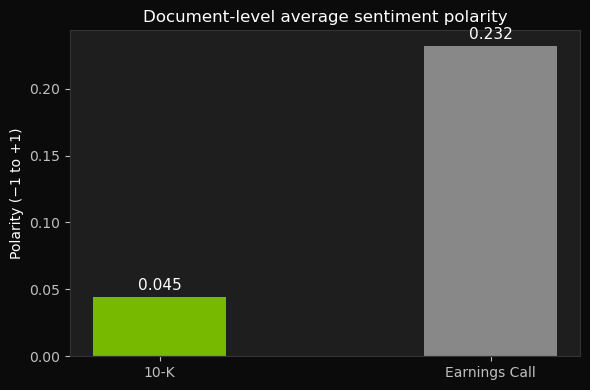

In [33]:
import matplotlib.pyplot as plt

bg_color = "#0B0B0B"
axes_color = "#1E1E1E"
text_color = "#FFFFFF"
secondary_text = "#BFBFBF"
nvidia_green = "#76B900"
neutral_gray = "#888888"

labels = ["10-K", "Earnings Call"]
values = [tenk_sentiment, earnings_sentiment]

fig, ax = plt.subplots(figsize=(6, 4), facecolor=bg_color)
ax.set_facecolor(axes_color)

# Bars
bars = ax.bar(labels, values, color=[nvidia_green, neutral_gray], width=0.4)

# Zero line 
ax.axhline(0, color="#333333", linewidth=0.8)

# Titles and labels
ax.set_title(
    "Document-level average sentiment polarity",
    color=text_color,
    fontsize=12
)
ax.set_ylabel("Polarity (−1 to +1)", color=text_color)

# Tick styling
ax.tick_params(axis='x', colors=secondary_text)
ax.tick_params(axis='y', colors=secondary_text)

# Value labels
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + (0.003 if val >= 0 else -0.01),  # handles negative values nicely
        f"{val:.3f}",
        ha="center",
        va="bottom" if val >= 0 else "top",
        color=text_color,
        fontsize=11
    )

# Borders
for spine in ax.spines.values():
    spine.set_color("#333333")

plt.tight_layout()
plt.savefig("Sentiment (NVIDIA).png", dpi=300, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

# Part II: Data Analysis

In [2]:
import sqlite3

conn = sqlite3.connect("icio.db")
cursor = conn.cursor()

In [3]:
import pandas as pd

# **Reading in all tables**

> Read in the dataset of '2025 Inter-Country Input-Output (ICIO) tables'.

In [4]:
va = pd.read_csv("VAcomponents.csv")
va.to_sql("ICIO_VA", conn, if_exists="replace", index=False)

query = """
SELECT *
FROM ICIO_va
"""
pd.read_sql(query, conn)

,country,year,industry,variable,mlln_USD
0,AGO,1995,A01,VALU,322.476
1,ARE,1995,A01,VALU,969.707
2,ARG,1995,A01,VALU,20184.998
3,AUS,1995,A01,VALU,10561.221
4,AUT,1995,A01,VALU,4012.326
...,...,...,...,...,...
680395,UKR,2022,T,DISC,0.000
680396,USA,2022,T,DISC,0.000
680397,VNM,2022,T,DISC,0.000
680398,ZAF,2022,T,DISC,0.000


> Read in the ICIO industry code table

In [9]:
icio = pd.read_excel("ICIO25.xlsx", engine="openpyxl", sheet_name = "Area_Activities", skiprows = 2, usecols = [9,10])
icio = icio.rename(columns={"Code.1" : "Code"})

icio.to_sql("ICIO_codes", conn, if_exists = "replace", index = False)
query = """
SELECT *
FROM ICIO_codes
"""
pd.read_sql(query, conn)

/opt/anaconda3/lib/python3.13/site-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: ColItems!$A:$E.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: RowItems!$A:$E.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


,Code,Industry
0,A01,Agriculture and hunting
1,A02,Forestry and logging
2,A03,Fishing and aquaculture
3,B05,Mining of coal and lignite
4,B06,Extraction of crude petroleum and natural gas
5,B07,Mining of metal ores
6,B08,Other mining and quarrying
7,B09,Mining support service activities
8,C10T12,Manufacture of food products; beverages and to...
9,C13T15,"Manufacture of textiles, wearing apparel, leat..."


> Read in WSTS table, but this had to be reformatted because of the way the WSTS table is

In [10]:
import pandas as pd
import re
from pathlib import Path

def load_wsts_monthly_long(filepath, sheet_name=0, month_keywords=None, verbose=False):
    """
    Load a WSTS-style Excel sheet (with title rows, a single header row containing month names,
    then repeated year marker rows like '2002' followed by region rows) and return a tidy long DataFrame:
      columns: ['Country', 'date', 'value'] where 'date' is a datetime (monthly) and 'value' numeric.
    """
    if month_keywords is None:
        month_keywords = ['January','February','March','April','May','June',
                          'July','August','September','October','November','December']
    df0 = pd.read_excel(filepath, sheet_name=sheet_name, header=None, engine='openpyxl')
    if verbose:
        print("Shape read (no header):", df0.shape)
    header_row = None
    for i, row in df0.iterrows():
        row_text = ' '.join([str(x) if pd.notna(x) else '' for x in row]).lower()
        count = sum(1 for m in month_keywords if m.lower() in row_text)
        if count >= 6:   # heuristic: at least half the months found in that row
            header_row = i
            break
    if header_row is None:
        raise ValueError("Could not detect header row containing month names. Try specifying manually.")
    if verbose:
        print("Detected header row:", header_row)
    df = pd.read_excel(filepath, sheet_name=sheet_name, header=header_row, engine='openpyxl')
    df.columns = [str(c).strip() for c in df.columns]
    if verbose:
        print("Columns:", df.columns.tolist()[:20])
    
    country_col = None
    for c in df.columns[:3]:
        if re.search(r'country|countries|region|economy', str(c), re.I):
            country_col = c
            break
    if country_col is None:
        country_col = df.columns[0]  # fallback
    if verbose:
        print("Using country column:", country_col)
    
    cc = df[country_col].astype(str).str.strip()
    year_mask = cc.str.match(r'^\d{4}$')  # rows that are exactly a 4-digit year

    df['Year_marker'] = df.loc[year_mask, country_col]
    df['Year'] = df['Year_marker'].ffill()
    df = df[~year_mask].copy()
    df.drop(columns=['Year_marker'], inplace=True)
   
    df[country_col] = df[country_col].astype(str).str.strip()
    df = df[df[country_col].notna()]
    df = df[~df[country_col].str.match(r'^(Total|Worldwide|Total Year|All numbers|©)', flags=re.I)]
    
    month_cols = [m for m in month_keywords if m in df.columns]
    if not month_cols:
        month_cols = [c for c in df.columns if any(m[:3] in str(c) for m in month_keywords)]
    if verbose:
        print("Detected month columns:", month_cols)
    keep_cols = [country_col, 'Year'] + month_cols
    df = df.loc[:, keep_cols]
    
    for col in month_cols:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[,\(\)]', '', regex=True).replace('nan',''), errors='coerce')
    df_long = df.melt(id_vars=[country_col, 'Year'], value_vars=month_cols,
                      var_name='Month', value_name='Value')

    df_long['Year'] = pd.to_numeric(df_long['Year'], errors='coerce').astype('Int64')
    month_map = {m: i+1 for i, m in enumerate(month_keywords)}
    
    def month_to_num(m):
        m = str(m)
        for name, num in month_map.items():
            if name.lower()[:3] in m.lower()[:3]:
                return num
        # fallback: try to parse int
        try:
            return int(m)
        except:
            return None
    df_long['month_num'] = df_long['Month'].apply(month_to_num)
    df_long['date'] = pd.to_datetime(df_long['Year'].astype(str) + '-' + df_long['month_num'].astype(str) + '-01', errors='coerce')
  
    df_long = df_long.rename(columns={country_col: 'Country', 'Value': 'Billings'})
    df_long = df_long[['Country', 'Year', 'Month', 'date', 'Billings']].sort_values(['Country','date']).reset_index(drop=True)
    return df_long


file_path = Path("WSTS-Historical-Billings-Report-Nov_2025.xlsx")   # <- set correct path
df_long = load_wsts_monthly_long(file_path, verbose=True)
df_long.head()

Shape read (no header): (244, 18)
Detected header row: 3
Columns: ['Unnamed: 0', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December', 'Total Year', 'Q1', 'Q2', 'Q3', 'Q4']
Using country column: Unnamed: 0
Detected month columns: ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


/var/folders/zs/v1jd9jg11q3bl6cqs71w554c0000gn/T/ipykernel_23216/1415420751.py:47: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Year'] = df['Year_marker'].ffill()


,Country,Year,Month,date,Billings
0,Americas,1986,January,1986-01-01,555850.0
1,Americas,1986,February,1986-02-01,633465.0
2,Americas,1986,March,1986-03-01,756220.0
3,Americas,1986,April,1986-04-01,689470.0
4,Americas,1986,May,1986-05-01,718336.0


In [11]:
df_long.to_sql("wsts_bills", conn, if_exists = "replace", index = False)

query = """
SELECT *
FROM wsts_bills
"""
pd.read_sql(query, conn)

,Country,Year,Month,date,Billings
0,Americas,1986,January,1986-01-01 00:00:00,555850.0
1,Americas,1986,February,1986-02-01 00:00:00,633465.0
2,Americas,1986,March,1986-03-01 00:00:00,756220.0
3,Americas,1986,April,1986-04-01 00:00:00,689470.0
4,Americas,1986,May,1986-05-01 00:00:00,718336.0
...,...,...,...,...,...
1915,Japan,2025,August,2025-08-01 00:00:00,3708778.0
1916,Japan,2025,September,2025-09-01 00:00:00,3951193.0
1917,Japan,2025,October,2025-10-01 00:00:00,3778338.0
1918,Japan,2025,November,2025-11-01 00:00:00,3701560.0


> Read in the the table of all domestic activities of Taiwan (2022) from the ICIO website

In [12]:
twn_dom = pd.read_csv("TWN2022dom.csv")
twn_dom.to_sql("TWN_Domestic", conn, if_exists = "replace", index = False)

query = """
SELECT *
FROM TWN_Domestic
"""
pd.read_sql(query, conn)

,Unnamed: 0,A01,A02,A03,B05,B06,B07,B08,B09,C10T12,...,HFCE,NPISH,GGFC,GFCF,INVNT,DPABR,CONS_NONRES,EXPO,..,TOTAL
0,DOM_A01,2330.145,0.343,10.331,0.000,0.000,0.000,0.000,0.000,7214.250,...,7288.474,1.226,0.269,93.820,1.122,0.000,159.260,384.409,0,18762.185
1,DOM_A02,1.597,0.036,0.028,0.006,0.000,0.000,0.000,0.000,5.144,...,6.483,0.427,0.072,8.519,0.010,0.000,0.344,3.781,0,64.504
2,DOM_A03,1.166,0.017,34.922,0.000,0.000,0.000,0.000,0.000,67.128,...,1204.744,0.232,0.000,0.006,3.698,0.000,13.114,1218.504,0,2753.909
3,DOM_B05,0.006,0.000,0.002,0.254,0.002,0.056,0.331,0.199,0.719,...,3.099,0.000,0.006,0.205,0.000,0.000,0.000,47.031,0,262.143
4,DOM_B06,0.000,0.000,0.000,0.000,0.406,0.000,0.001,0.001,0.003,...,0.017,0.000,0.004,0.157,0.000,0.000,0.000,31.529,0,564.322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,IMP_OTHER,0.691,0.028,2.911,0.577,0.777,0.397,3.944,2.263,-5.399,...,537.188,0.347,58.887,574.710,1.470,1246.254,0.000,0.000,0,4736.129
101,TXS_INT_FNL,-33.711,0.359,17.993,2.056,1.413,1.403,13.652,8.506,-268.875,...,9953.556,47.480,639.998,7853.992,12.395,0.000,495.156,941.671,0,24523.348
102,TTL_INT_FNL,9759.209,25.188,1540.231,139.208,172.180,90.896,938.323,511.423,26650.571,...,322818.511,5579.024,105949.692,213652.245,359.615,16582.488,11062.907,490220.376,0,2050569.909
103,VALU,9002.979,39.316,1213.678,122.935,392.142,90.133,778.548,416.602,11265.850,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,736289.903


> Check that all tables were saved in as an SQL scheme

In [13]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
cursor.fetchall()

[('ICIO_VA',), ('ICIO_codes',), ('wsts_bills',), ('TWN_Domestic',)]

> Find the industries that are relevant to the Semi-conductor Industry

In [14]:
query = """
SELECT Code, Industry
FROM ICIO_codes
WHERE Industry LIKE '%electrical%' OR Industry LIKE '%computer%' OR Industry LIKE '%Hardware%';
"""
pd.read_sql(query, conn)

,Code,Industry
0,C26,"Manufacture of computer, electronic and optica..."
1,C27,Manufacture of electrical equipment
2,J62_63,Computer programming and information service a...


>Code C26 will be the primary industry code we will look at. 

> Find the sum for the Industry that we chose ^ up there. This is the sum of all the spendings of of all the countries. The global share of this industry. 

In [15]:
query = """
SELECT SUM(mlln_USD)
FROM ICIO_va
WHERE (Industry LIKE '%C26%' OR Industry LIKE '%C27%' OR Industry LIKE '%C28%') AND Year LIKE '%2022%';
"""
pd.read_sql(query, conn)

,SUM(mlln_USD)
0,6718561.832


In [16]:
query = """
SELECT SUM(mlln_USD)
FROM ICIO_va
WHERE (Industry LIKE '%C26%' OR Industry LIKE '%C27%' OR Industry LIKE '%C28%') 
AND Year LIKE '%2022%' AND Country LIKE '%TWN%';
"""
print(pd.read_sql(query, conn))

print(f"{(308826.442/4269336.509*100): .2f}%")

   SUM(mlln_USD)
0     330023.484
 7.23%


>> Global Semiconductor VA

> Do the same but only for Taiwan

In [17]:
query = """
SELECT SUM(mlln_USD)
FROM ICIO_va
WHERE (Industry LIKE '%C26%' OR Industry LIKE '%C27%' OR Industry LIKE '%C28%') 
AND Year LIKE '%2022%' AND Country LIKE '%TWN%';
"""
print(pd.read_sql(query, conn))

print(f"{(308826.442/4269336.509*100): .2f}%")

   SUM(mlln_USD)
0     330023.484
 7.23%


>> Taiwan's Semiconductor Share in 2022

> For every year, compare the global semi conductor industry compared to Taiwan's. Then look at Taiwan's % share. And Plot it

In [18]:
query = """
WITH semi AS (
SELECT Year, Country, mlln_USD
FROM ICIO_va
WHERE Industry In ('C26', 'C27', 'C28')
), 
global_VA AS (
SELECT Year, Sum(mlln_USD) AS global_va
FROM semi
GROUP BY Year), 
twn_va AS(
SELECT Year, SUM(mlln_USD) AS twn_va
FROM semi 
WHERE Country = 'TWN'
GROUP BY Year
)
SELECT
    g.Year,
    g.global_va,
    COALESCE(t.twn_va, 0)            AS twn_va,
    CASE
      WHEN g.global_va = 0 OR g.global_va IS NULL THEN NULL
      ELSE (1.0 * COALESCE(t.twn_va, 0)) / g.global_va
    END                              AS twn_share
FROM global_va g
LEFT JOIN twn_va t USING(Year)
ORDER BY g.Year DESC
"""
twn_share = pd.read_sql(query, conn)
twn_share.head()

,Year,global_va,twn_va,twn_share
0,2022,6718561.832,330023.484,0.049121
1,2021,6749301.960,315469.012,0.046741
2,2020,5826977.374,251344.055,0.043135
3,2019,5868608.109,203839.901,0.034734
4,2018,5996295.220,210956.987,0.035181


In [19]:
import matplotlib.pyplot as plt
import numpy as np

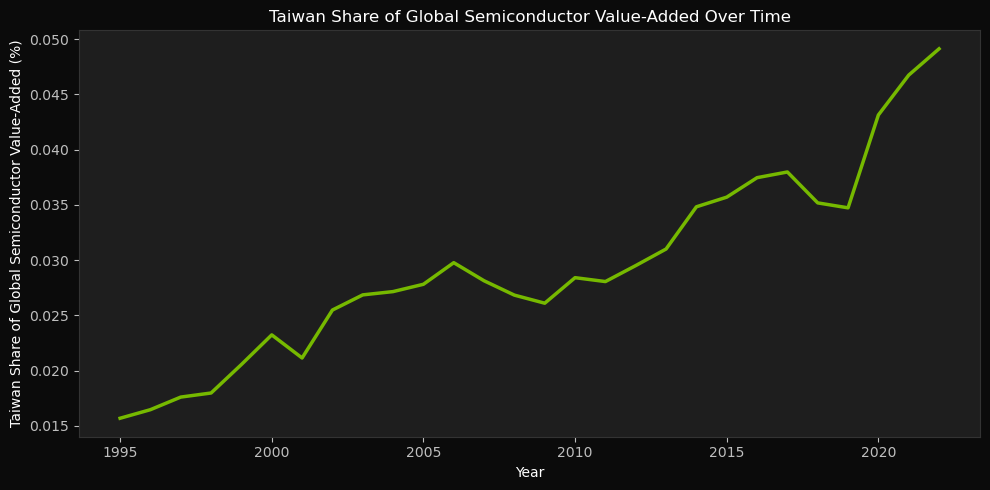

In [20]:
bg_color = "#0B0B0B"
axes_color = "#1E1E1E"
text_color = "#FFFFFF"
secondary_text = "#BFBFBF"
nvidia_green = "#76B900"

fig, ax = plt.subplots(figsize=(10, 5), facecolor=bg_color)
ax.set_facecolor(axes_color)

# Line plot
ax.plot(
    twn_share['Year'],
    twn_share['twn_share'],
    color=nvidia_green,
    linewidth=2.5
)

# Titles and labels
ax.set_xlabel("Year", color=text_color)
ax.set_ylabel("Taiwan Share of Global Semiconductor Value-Added (%)", color=text_color)
ax.set_title(
    "Taiwan Share of Global Semiconductor Value-Added Over Time",
    color=text_color,
    fontsize=12
)

# Tick styling
ax.tick_params(axis='x', colors=secondary_text)
ax.tick_params(axis='y', colors=secondary_text)

# Borders
for spine in ax.spines.values():
    spine.set_color("#333333")

plt.tight_layout()
plt.savefig("Taiwan Share of Semiconductor Manufacturing (NVIDIA).png", dpi=300, facecolor=fig.get_facecolor(), bbox_inches="tight")
plt.show()

> Plot the billings of WSTS by region to show growth in Asia compared to other industries

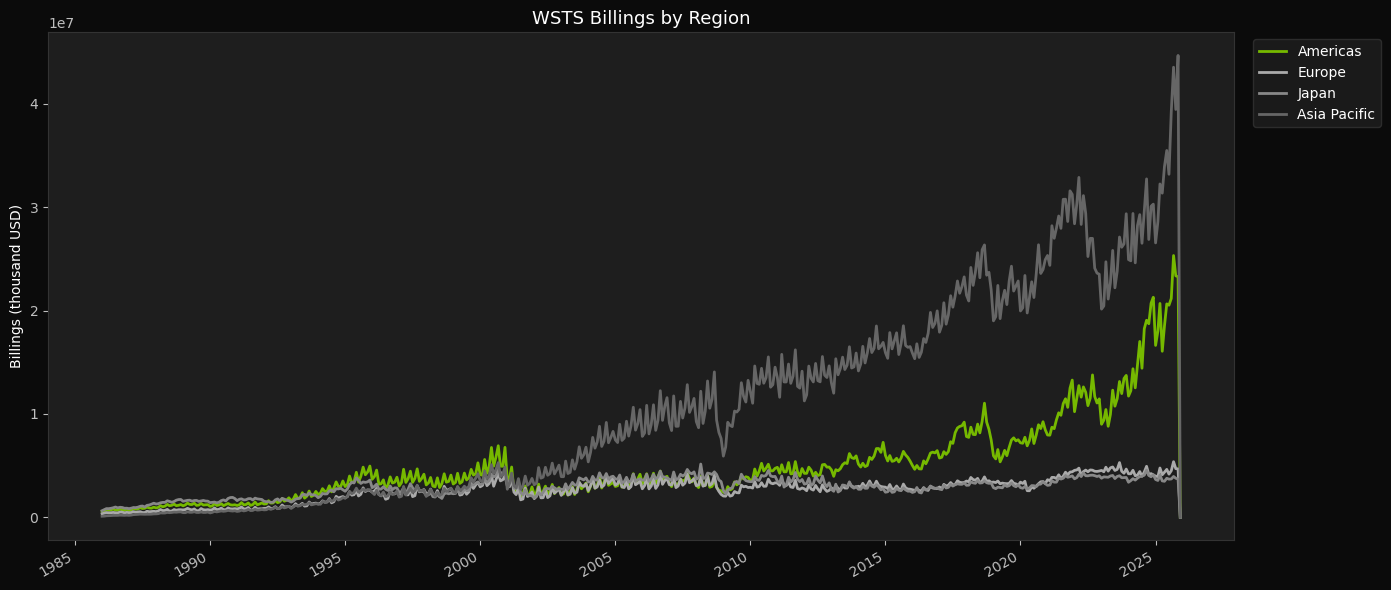

In [21]:
# pivot table to select regions
pivot = df_long.pivot_table(index='date', columns='Country', values='Billings', aggfunc='sum').sort_index()


regions = ['Americas','Europe','Japan','Asia Pacific','Worldwide']  
regions = [r for r in regions if r in pivot.columns]  

bg_color = "#0B0B0B"
axes_color = "#1E1E1E"
text_color = "#FFFFFF"
secondary_text = "#BFBFBF"

nvidia_green = "#76B900"
gray1 = "#AAAAAA"
gray2 = "#888888"
gray3 = "#666666"
gray4 = "#444444"

color_map = {
    "Americas": nvidia_green,   # highlight
    "Europe": gray1,
    "Japan": gray2,
    "Asia Pacific": gray3,
    "Worldwide": gray4
}

fig, ax = plt.subplots(figsize=(14, 6), facecolor=bg_color)
ax.set_facecolor(axes_color)

for region in regions:
    series = pivot[region].dropna()
    ax.plot(
        series.index,
        series.values,
        label=region,
        linewidth=2,
        color=color_map.get(region, "#999999")
    )

# Titles and labels
ax.set_title("WSTS Billings by Region", color=text_color, fontsize=13)
ax.set_ylabel("Billings (thousand USD)", color=text_color)
ax.set_xlabel("", color=text_color)

# Tick styling
ax.tick_params(axis='x', colors=secondary_text)
ax.tick_params(axis='y', colors=secondary_text)

# Legend styling (clean + readable)
legend = ax.legend(
    facecolor=axes_color,
    edgecolor="#333333",
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)
for text in legend.get_texts():
    text.set_color(text_color)

# Borders
for spine in ax.spines.values():
    spine.set_color("#333333")

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("WSTS Billings (NVIDIA).png", dpi=300, facecolor=fig.get_facecolor(),bbox_inches="tight")
plt.show()